In [37]:
import h5py
import numpy as np

# Generate dummy data for the example
image_shape = (256, 256, 3)
num_images = 100000
dummy_data = np.random.random((num_images,) + image_shape)

# Define the chunk sizes to test
chunk_sizes = [(100, 256, 256, 3), (1000, 256, 256, 3), None]
ds_names = ['chuck_100', 'chunk_1000', 'non-chunked']

# Iterate over chunk sizes
file_name = f"test_chunk.h5"

# Create the H5 file
with h5py.File(file_name, 'a') as file:
    for chunk_size, ds_name in zip(chunk_sizes, ds_names):
        # Create the dataset
        dataset = file.create_dataset(ds_name, shape=dummy_data.shape, chunks=chunk_size)

        # Write the data to the dataset
        dataset[:] = dummy_data

        print(f"Dataset with chunk size {chunk_size} created in '{ds_name}' dataset")

Dataset with chunk size (100, 256, 256, 3) created in 'chuck_100' dataset
Dataset with chunk size (1000, 256, 256, 3) created in 'chunk_1000' dataset
Dataset with chunk size None created in 'non-chunked' dataset


In [38]:
class hdf5_dataset(Dataset):
    
    def __init__(self, file_path, transform, key):
        self.file_path = file_path
        self.hf = None
        self.transform = transform
        self.key = key
        
    def __len__(self):
        with h5py.File(self.file_path, 'r') as f:
            self.len = len(f[self.key])
        return self.len
    
    def __getitem__(self, idx):
        if self.hf is None:
            self.hf = h5py.File(self.file_path, 'r')
            
        image = np.array(self.hf[self.key][idx])
        if self.transform:
            image = self.transform(image)        
        return image

In [39]:
%%time
valid_ds = hdf5_dataset('test_chunk.h5', transform=transforms.ToTensor(), key='chuck_100')
valid_dl = DataLoader(valid_ds, batch_size=16, shuffle=True, num_workers=4)
for i in range(5):
    batch = next(iter(valid_dl))

CPU times: user 32.2 s, sys: 33.1 s, total: 1min 5s
Wall time: 45.4 s


In [40]:
%%time
valid_ds = hdf5_dataset('test_chunk.h5', transform=transforms.ToTensor(), key='chunk_1000')
valid_dl = DataLoader(valid_ds, batch_size=16, shuffle=True, num_workers=4)
for i in range(5):
    batch = next(iter(valid_dl))

CPU times: user 31.2 s, sys: 32.1 s, total: 1min 3s
Wall time: 43.6 s


In [41]:
%%time
valid_ds = hdf5_dataset('test_chunk.h5', transform=transforms.ToTensor(), key='non-chunked')
valid_dl = DataLoader(valid_ds, batch_size=16, shuffle=True, num_workers=4)
for i in range(5):
    batch = next(iter(valid_dl))

CPU times: user 35 s, sys: 32.3 s, total: 1min 7s
Wall time: 44 s


In [1]:
import os
import math
import time
import operator
import datetime
import h5py
from tqdm import tqdm
import wandb

import numpy as np
from scipy.ndimage import rotate
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.image as image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.modules.utils import _pair, _quadruple
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import torchvision

import sys
sys.path.append('/scratch/yichen/notebooks/helper_functions/')
from visualization_functions import show_images

def list_to_dict(lst):
    dictionary = {}
    for index, item in enumerate(lst):
        dictionary[index] = item
    return dictionary

def viz_dataloader(dl, n=8, hist=True, label_converter=None):
    batch = next(iter(dl))
    if len(batch[0]) < n: 
        raise ValueError("n is smaller than batch size, increase n")
    inputs = batch[0][:n]
    labels = list(batch[1][:n].numpy())
    if label_converter:
        for i in range(len(labels)):
            labels[i] = label_converter[labels[i]]
    show_images(torch.permute(inputs, [0,2,3,1]).cpu().numpy(), labels=labels, hist_bins=100)            

class hdf5_dataset(Dataset):
    
    def __init__(self, file_path, folder='train', transform=None, classes=[]):
        self.file_path = file_path
        self.folder = folder
        self.transform = transform
        self.hf = None

    def __len__(self):
        with h5py.File(self.file_path, 'r') as f:
            self.len = len(f[self.folder]['labels'])
        return self.len
    
    def __getitem__(self, idx):
        if self.hf is None:
            self.hf = h5py.File(self.file_path, 'r')
            
        image = np.array(self.hf[self.folder]['data'][idx])
        labels = np.array(self.hf[self.folder]['labels'][idx])
        
        if self.transform:
            image = self.transform(image)
        return image, labels

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

In [2]:
train_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_train.h5', folder='train', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=4)

In [11]:
%%time
batch = next(iter(train_dl))

CPU times: user 9.08 s, sys: 784 ms, total: 9.87 s
Wall time: 1h 43min 44s


In [ ]:
%%time
batch = next(iter(train_dl))

In [6]:
valid_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_2m_valid.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=256, shuffle=True, num_workers=4)
# viz_dataloader(valid_dl, label_converter=label_converter)

In [7]:
%%time
batch = next(iter(valid_dl))

CPU times: user 9.03 s, sys: 394 ms, total: 9.42 s
Wall time: 7min 22s


In [4]:
valid_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_2m_valid_unchunked.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=256, shuffle=True, num_workers=4)
# viz_dataloader(valid_dl, label_converter=label_converter)

In [5]:
%%time
batch = next(iter(valid_dl))

CPU times: user 8.36 s, sys: 310 ms, total: 8.67 s
Wall time: 1.37 s


In [2]:
# imagenet
train_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_2m_valid.h5', folder='valid', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=4)
# viz_dataloader(train_dl, label_converter=label_converter)

valid_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_2m_valid.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=256, shuffle=True, num_workers=4)
# viz_dataloader(valid_dl, label_converter=label_converter)

test_ds = hdf5_dataset('/scratch/yichen/atom_v4_rot_2m.h5', folder='test', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=256, shuffle=True, num_workers=4)
# viz_dataloader(test_dl)

In [9]:
%%time
batch = next(iter(train_dl))

CPU times: user 7.55 s, sys: 400 ms, total: 7.95 s
Wall time: 5min 7s


In [4]:
%%time
batch = next(iter(train_dl))

CPU times: user 7.32 s, sys: 319 ms, total: 7.64 s
Wall time: 6min 52s


In [6]:
n = 8

In [7]:
if len(batch[0]) < n: 
    raise ValueError("n is smaller than batch size, increase n")
inputs = batch[0][:n]
labels = list(batch[1][:n].numpy())
if label_converter:
    for i in range(len(labels)):
        labels[i] = label_converter[labels[i]]

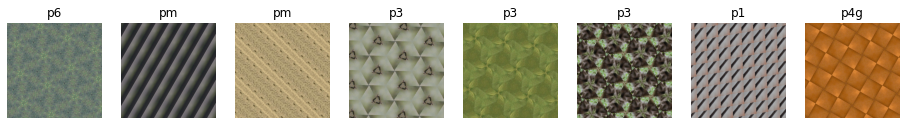

In [8]:
show_images(torch.permute(inputs, [0,2,3,1]).cpu().numpy(), labels=labels, hist_bins=100)     

In [3]:
def train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                 epochs, start=0, scheduler=None, 
                 model_name=None, model_dir=None, tracking=False):

    # make directory for the model
    if model_dir and not os.path.isdir(model_dir): os.mkdir(model_dir)

    history = []
    
    if tracking:   
        wandb.watch(model, log_freq=100)
        
    for epoch_idx in range(start, epochs+start):
                
        print("Epoch: {}/{}".format(epoch_idx+1, epochs+start))
        
        avg_train_loss, avg_train_acc = train(model, loss_func, optimizer, device, train_dl, 
                              scheduler=scheduler, tracking=tracking)
        
        avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, valid_dl, 
                              tracking=tracking)
        
        history.append([avg_train_loss, avg_valid_loss])
        
        if test_dl:
            avg_test_loss, avg_test_acc = valid(model, loss_func, device, test_dl, tracking=tracking)
            history.append(avg_test_loss)
            
        if tracking:   
            # record the epoch loss and accuracy:            
            if test_dl:
                wandb.log({'epoch':epoch_idx, 
                           "train_loss": avg_train_loss, 
                           "valid_loss": avg_valid_loss,
                           "train_acc": avg_train_acc, 
                           "valid_acc": avg_valid_acc,
                           "test_loss": avg_test_loss,
                           "test_acc": avg_test_acc})
            else:
                wandb.log({"epoch": epoch_idx,
                           "train_loss": avg_train_loss, 
                           "valid_loss": avg_valid_loss,
                           "train_acc": avg_train_acc, 
                           "valid_acc": avg_valid_acc}) 
                
        if model_name != None:
            torch.save(model, os.path.join(model_dir, model_name+'-epoch-{}.pt'.format(epoch_idx+1)))
                
    return history


def train(model, loss_func, optimizer, device, train_dl, scheduler=None, tracking=False):

    train_data_size = len(train_dl.dataset)
    start_time = time.time()

    # Set to training mode
    model.train()

    # Loss and Accuracy within the epoch
    train_loss = 0.0
    train_acc = 0.0

    for i, batch in enumerate(tqdm(train_dl)):
        inputs = batch[0].to(device).float()
        labels = batch[1].to(device).long()
        model = model.to(device)

        # Clean existing gradients
        optimizer.zero_grad()

        # Forward pass - compute outputs on input data using the model
        outputs = model(inputs)

        # Compute loss
        loss = loss_func(outputs, labels) 

        # Compute the total loss for the batch and add it to train_loss
        train_loss += loss.item() * inputs.size(0)
        
        # Compute the accuracy
        ret, predictions = torch.max(outputs.data, 1)
        correct_counts = predictions.eq(labels.data.view_as(predictions))

        # Convert correct_counts to float and then compute the mean
        acc = torch.mean(correct_counts.type(torch.FloatTensor))

        # Compute total accuracy in the whole batch and add to train_acc
        train_acc += acc.item() * inputs.size(0)
            
        # Backpropagate the gradients
        loss.backward()

        # Update the parameters
        optimizer.step()
        if scheduler:
            scheduler.step()

    # Find average training loss and training accuracy
    avg_train_loss = train_loss/train_data_size 
    avg_train_acc = train_acc/float(train_data_size)
    print("Training: Loss: {:.4f}, Accuracy: {:.4f}%, Time: {:.4f}s".format(avg_train_loss, avg_train_acc*100, time.time()-start_time))

    return avg_train_loss, avg_train_acc


def valid(model, loss_func, device, valid_dl, tracking=False):

    valid_data_size = len(valid_dl.dataset)

    # Loss and Accuracy within the epoch
    valid_loss = 0.0
    valid_acc = 0.0
    
    start_time = time.time()
        
    # Validation - No gradient tracking needed
    with torch.no_grad():

        # Set to evaluation mode
        model.eval()

        # Validation loop
        
        for j, batch in enumerate(tqdm(valid_dl)):
            
            inputs = batch[0].float().to(device)
            labels = batch[1].long().to(device)

            model = model.to(device)

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)
            
            # Compute loss
            loss = loss_func(outputs, labels) 
            
            # Compute the total loss for the batch and add it to valid_loss
            valid_loss += loss.item() * inputs.size(0)
            # Calculate validation accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to valid_acc
            valid_acc += acc.item() * inputs.size(0)     
            
    # Find average training loss and training accuracy
    avg_valid_loss = valid_loss/valid_data_size 
    avg_valid_acc = valid_acc/float(valid_data_size)
    print("Validation : Loss : {:.4f}, Accuracy: {:.4f}%, Time: {:.4f}s".format(avg_valid_loss, avg_valid_acc*100, time.time()-start_time))

    return avg_valid_loss, avg_valid_acc

In [4]:
model = models.resnet50()

model.fc = nn.Sequential(nn.BatchNorm1d(2048),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features = 2048, out_features=512, bias=False),
                         nn.ReLU(inplace=True),

                         nn.BatchNorm1d(512),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features = 512, out_features=64, bias=False),
                         nn.ReLU(inplace=True),
                         
                         nn.BatchNorm1d(64),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features=64, out_features=17, bias=True)
                        )

In [5]:
model(torch.randn(2,3,256,256)).shape

torch.Size([2, 17])

# train

In [6]:
config = {
    'device': torch.device('cuda:2'),
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
    'dropout': 0.5
}

NAME = 'benchmark-test-05312023'

wandb.init(project='symmetry_paper', entity='yig319', 
           name=NAME, config=config, id=NAME)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [ ]:
device = config['device']
lr = 1e-3
epochs = 1

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, valid_dl, train_dl, test_dl,
                       epochs=epochs, start=0, scheduler=scheduler, model_name=NAME, 
                       model_dir='/scratch/yichen/models/', tracking=False)

Epoch: 1/1


  0%|          | 0/7813 [00:00<?, ?it/s]

In [10]:
config = {
    'device': torch.device('cuda:3'),
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
    'dropout': 0.5
}

NAME = 'benchmark-resnet50_from_scratch-v4_10m-05312023'

wandb.init(project='symmetry_paper', entity='yig319', 
           name=NAME, config=config, id=NAME)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [12]:
device = config['device']
lr = 1e-3
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=0, scheduler=scheduler, model_name=NAME, 
                       model_dir='/scratch/yichen/models/', tracking=True)

Epoch: 1/10


100%|██████████| 2741/2741 [24:30<00:00,  1.86it/s]


Training: Loss: 0.9895, Accuracy: 64.3200%, Time: 1470.3402s


100%|██████████| 2597/2597 [09:26<00:00,  4.58it/s]


Validation : Loss : 0.9627, Accuracy: 64.9332%, Time: 566.7201s


...

Validation : Loss : 0.1920, Accuracy: 93.4388%, Time: 564.5155s


100%|██████████| 167/167 [02:36<00:00,  1.06it/s]


Validation : Loss : 2.5025, Accuracy: 45.6952%, Time: 156.8675s
Epoch: 7/10


 26%|██▌       | 715/2741 [06:31<18:29,  1.83it/s]


FileNotFoundError: Caught FileNotFoundError in DataLoader worker process 1.
Original Traceback (most recent call last):
  File "/scratch/yichen/anaconda3/envs/gyc/lib/python3.8/site-packages/torch/utils/data/_utils/worker.py", line 287, in _worker_loop
    data = fetcher.fetch(index)
  File "/scratch/yichen/anaconda3/envs/gyc/lib/python3.8/site-packages/torch/utils/data/_utils/fetch.py", line 44, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/scratch/yichen/anaconda3/envs/gyc/lib/python3.8/site-packages/torch/utils/data/_utils/fetch.py", line 44, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/scratch/yichen/anaconda3/envs/gyc/lib/python3.8/site-packages/torchvision/datasets/folder.py", line 232, in __getitem__
    sample = self.loader(path)
  File "/scratch/yichen/anaconda3/envs/gyc/lib/python3.8/site-packages/torchvision/datasets/folder.py", line 269, in default_loader
    return pil_loader(path)
  File "/scr

# analyze

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

# imagenet 
def confusion_matrix(model, dataloader, classes, device, n_batches=1):
    model.eval()
    cm = torch.zeros(len(classes), len(classes))
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloader):

            inputs = inputs.to(device) 
            labels = labels.to(device)
            model = model.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            for t, p in zip(labels.view(-1), preds.view(-1)):
                cm[t.long(), p.long()] += 1
    cm = np.array(cm)

    print('Sum for true labels:')
    true_counts = np.expand_dims(np.sum(cm, axis=1), 0)
    display(pd.DataFrame(true_counts, columns=classes))

    wrong, right = 0, 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i == j: right+=cm[i,j]
            if i != j: wrong+=cm[i,j]
    print('Accuracy for these batches:', right/(right+wrong))
    return cm.astype(np.int32)

def plot_cm(cm, classes, save_file, title, style='simple'):

    if style == 'simple':
        fig = plt.figure(figsize=(12,10))
        ax = fig.subplots(1,1)
        ax.set_title('Confusion Matrix of'+title)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        disp = disp.plot(cmap=plt.cm.Blues, ax=ax)

    if style== 'with_axis':
        df_cm = pd.DataFrame(cm)
        df_cm.index.name = 'Actual'
        df_cm.columns.name = 'Predicted'

        fig = plt.figure(figsize=(12,10))
        ax = fig.subplots(1,1)
        ax.set_title('Confusion Matrix of'+title)

        res = sn.heatmap(df_cm, annot=True, square=True, cmap='Blues',
                         xticklabels = classes, yticklabels=classes, fmt='g', 
                         ax=ax, cbar_kws={'label': 'Number of Images'})

        res.axhline(y = 0, color = 'k', 
                    linewidth = 1)
        res.axhline(y = 16.98, color = 'k',
                    linewidth = 1)
        res.axvline(x = 0, color = 'k',
                    linewidth = 1)
        res.axvline(x = 16.98, color = 'k',
                    linewidth = 1)
    
    if save_file: plt.savefig(save_file, dpi=300)
    plt.show()

NAME = 'benchmark-resnet50_from_scratch-v4_10m-05312023'
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                    'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']

In [24]:
cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-train_cm.npy', cm)

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,46851.0,46837.0,46522.0,46547.0,47014.0,46745.0,46011.0,46915.0,46931.0,46916.0,46874.0,45985.0,46907.0,46876.0,46911.0,46907.0,46924.0


Accuracy for these batches: 0.9995847348532038


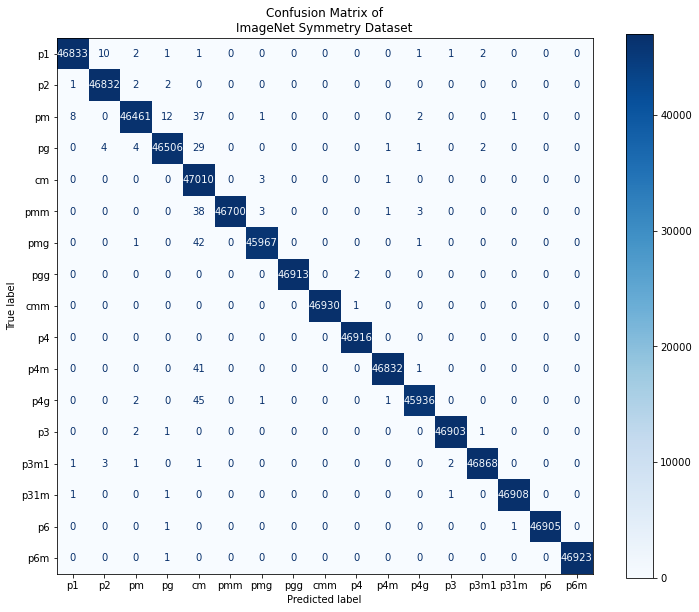

In [25]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [26]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-valid_cm.npy', cm)

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,46892.0,46864.0,46553.0,46544.0,47012.0,46787.0,29226.0,46905.0,46904.0,46918.0,33452.0,34487.0,46889.0,46891.0,46894.0,46905.0,46900.0


Accuracy for these batches: 0.9801958240319353


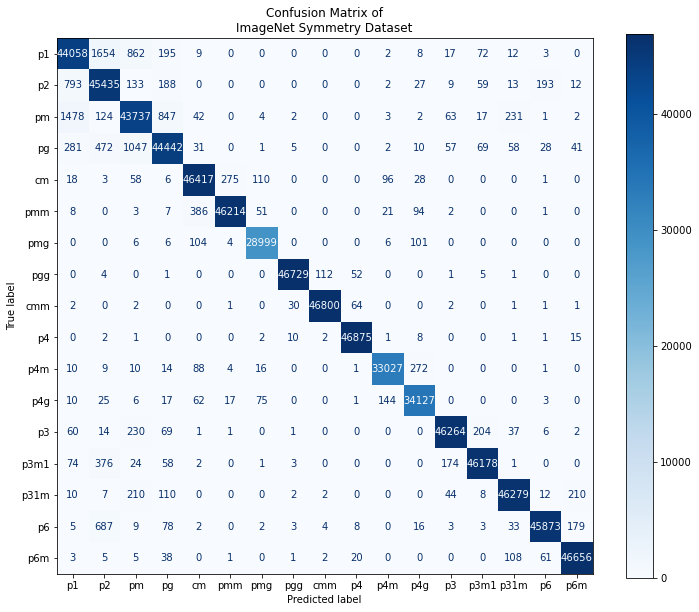

In [27]:
# cm = np.load('11172021-benchmark_imagenet-fpn_spatial-transfer_learning-valid.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [28]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-test_cm.npy', cm)

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0,11764.0


Accuracy for these batches: 0.48552913174790485


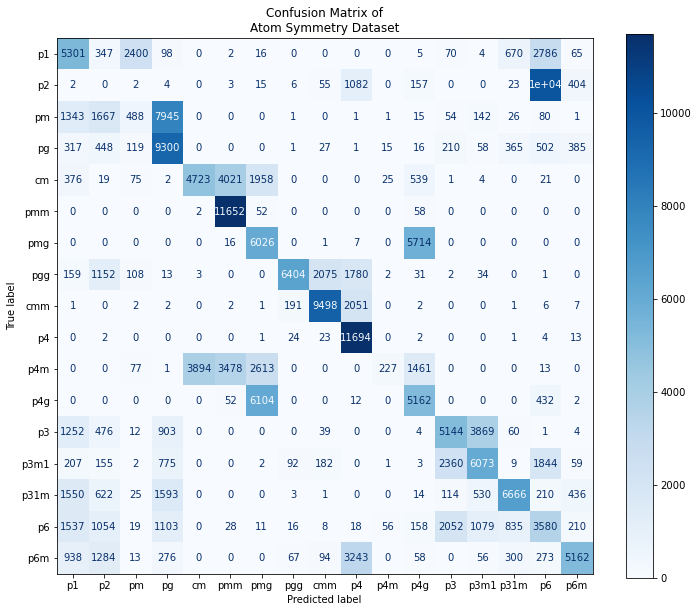

In [29]:
# cm = np.load('05232022-benchmark-resnet50_from_scratch-dataset_v3-test.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nAtom Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
from IPython.display import display_html
def restartkernel() :
    display_html("<script>Jupyter.notebook.kernel.restart()</script>",raw=True)
restartkernel()